In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import ascii
from astropy import units as u
from astropy.coordinates import SkyCoord, Distance
from astropy.cosmology import LambdaCDM as LCDM
import numpy.ma as ma
import healpy as hp
import matplotlib as mpl
import emcee

## My modules
from Clustering_module import *


DP2_DIRECTORY = "/home/vibin/MyFolder/WorkDesk/DP2/"

cosmo = LCDM(H0=71, Om0=0.26, Ode0=0.74, Ob0=0.0435)

schind_23_file_name = DP2_DIRECTORY + "Data/apjaca7cat7_ascii.txt"
schind_23_data = open(schind_23_file_name, 'r')
ra_col_schind_23 = []
dec_col_schind_23 = []
red_col_schind_23 = []
mag_col_schind_23 = []

skip_rows = 6
for line in schind_23_data:
    if (skip_rows > 0):
        skip_rows -= 1
        continue
    split_line = line.split()
    quasar_name = split_line[0] 
    red_col_schind_23.append(float(split_line[2]))
    ra_col_schind_23.append(float(quasar_name[4:13]))
    dec_col_schind_23.append(float(quasar_name[13:21]))

    mag_col_schind_23.append(float(split_line[3]))
    
ra_col_schind_23 = np.array(ra_col_schind_23)
dec_col_schind_23 = np.array(dec_col_schind_23)
red_col_schind_23 = np.array(red_col_schind_23)
mag_col_schind_23 = np.array(mag_col_schind_23)

DP2_DIRECTORY = "/home/vibin/MyFolder/WorkDesk/DP2/"


def find_red_clust_PS1_footprint(data_ra, data_dec, data_red, plot_fig=True, write_data=False, file_name_to_write=None):

    if write_data:
        if file_name_to_write == None:
            raise Exception("Please give a file name to write data")
        
    s_bins = np.arange(30,2000, 30)

    xi_s_array = ma.zeros_like(s_bins[:-1], dtype=float)
    xi_s_error_array = ma.zeros_like(s_bins[:-1], dtype=float)
    DD_count_array = ma.zeros_like(s_bins[:-1], dtype=float)
    RR_count_array = ma.zeros_like(s_bins[:-1], dtype=float)
    DR_count_array = ma.zeros_like(s_bins[:-1], dtype=float)
    num_runs = 1000

    for i in range(num_runs):
        rand_ra, rand_dec, rand_red = make_rand_cat_ps1(20, data_red)
        s_mid, xi_s, xi_s_error, DD_count, RR_count, DR_count= find_xi_s(data_ra, data_dec, data_red, s_bins, rand_ra=rand_ra, rand_dec=rand_dec,\
                                rand_red=rand_red, ret_result=True)
        plt.close()

        xi_s_array += xi_s
        xi_s_error_array += (xi_s_error)**2
        DD_count_array += DD_count
        RR_count_array += RR_count
        DR_count_array += DR_count

    xi_s_array = xi_s_array/num_runs
    xi_s_error_array = xi_s_error_array**0.5
    DD_count_array = DD_count_array/num_runs
    RR_count_array = RR_count_array/num_runs
    DR_count_array = DR_count_array/num_runs

    print(xi_s_array)
    print(xi_s_error_array)

    if plot_fig:
        mpl.rcParams['font.size'] = 18
        fign, axn = plt.subplots(figsize=(14,7))
        axn.axhline(0, ls = '--', lw = 0.5, c = 'black')

        axn.errorbar(s_mid, xi_s_array, xi_s_error_array, fmt='*', capsize=3)
        axn.set_ylabel(r'$\xi(s)$')
        axn.set_xlabel(r'$s (h^{-1}Mpc)$')
    
    if write_data:
        file = open(DP2_DIRECTORY + "Data/" + file_name_to_write + ".txt", 'w')
        file.write('  s_mid       DD      RR      DR      xi_s     Delta xi_s\n')
        for i in range(len(s_mid)):
            file.write(f'{s_mid[i]:9.3f}   {DD_count_array[i]:5d}    {RR_count_array[i]:5d}   {DR_count_array[i]:5d}   {xi_s_array[i]:8.5f}   {xi_s_error_array[i]:8.5f}\n')
        file.close()


### Plotting the PS1 quasar distribution, spatial and redshift

##### Plot: PS1 quasar distribution

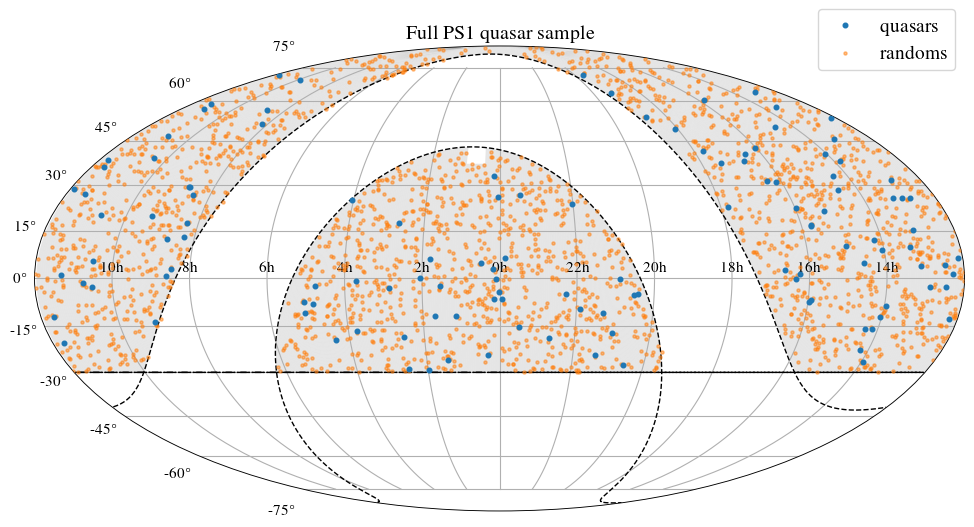

In [9]:
def plot_sky_map_ps1_v2(ra, dec, mask = None, title='', labels=['quasars'], mark_size=30):

    if (mask is None):
        mask = np.zeros_like(ra, dtype='int')
        mask = np.insert(mask, 0, 1)

    ### Plots the lines marking the excluded area of the galactic plane
    res = 511
    gal_l = np.linspace(0, 360, res)
    gal_b = np.ones(res) * 20.0
    gal_line_1 = SkyCoord(gal_l, gal_b, frame = 'galactic', unit = 'deg')
    gal_line_2 = SkyCoord(gal_l, -gal_b, frame = 'galactic', unit = 'deg')
    ### gal_line_equat is the galactic line in equatorial coordinates
    gal_line_equat_1 = gal_line_1.transform_to('icrs')   
    gal_line_equat_2 = gal_line_2.transform_to('icrs')
    gal_ra_1 = np.radians(range_wrapper(gal_line_equat_1.ra.degree))
    ###Sorting the array in order to do line plot
    i_sorted = np.argsort(gal_ra_1) 
    gal_ra_1 = gal_ra_1[i_sorted]
    gal_dec_1 = np.radians(gal_line_equat_1.dec.degree)[i_sorted]
    gal_ra_2 = np.radians(range_wrapper(gal_line_equat_2.ra.degree))
    i_sorted = np.argsort(gal_ra_2)
    gal_ra_2 = gal_ra_2[i_sorted]
    gal_dec_2 = np.radians(gal_line_equat_2.dec.degree)[i_sorted]
    ### dec -30 array is obtained
    dec_30_ra = np.radians(range_wrapper(np.linspace(0, 360, res)))
    dec_30_dec = np.radians(np.ones(res) * -30.0)

    fig, ax = plt.subplots(figsize = (12, 8), subplot_kw={'projection': 'mollweide'})
    plt.rcParams.update({'font.size': 12})
    plt.rc('legend', fontsize=14)
    #ax = plt.subplot(111, projection = "mollweide")

    ### This plots the footprint
    ax.plot(gal_ra_1, gal_dec_1, color = 'black', linestyle='--', linewidth = 1) 
    ax.plot(gal_ra_2, gal_dec_2, color = 'black', linestyle='--', linewidth = 1)
    ax.plot(dec_30_ra, dec_30_dec, color = 'black', linestyle='-.', linewidth = 1)
    #-------------------------------------------------------------------------------------------
    ### Plotting the sources
    ra = np.radians(range_wrapper(ra)) 
    dec = np.radians(dec)
    marker = ['o','x']

    ###shading the footprint surface------------------------------------------------------------------------------------------------

    gloc = np.where(gal_dec_1 < np.radians(-30))
    foot_x = (gal_ra_1 + np.pi)/(2 * np.pi)
    foot_y = gal_dec_1
    foot_y[gloc] = np.radians(-30)

    for i in range(len(foot_x) - 1):
        ax.axhspan(foot_y[i], np.radians(90), xmin=foot_x[i], xmax=foot_x[i+1], facecolor='grey', alpha =0.2, zorder=1)

    gloc = np.where(gal_dec_2 > np.radians(-30))
    foot_x2 = (gal_ra_2[gloc] + np.pi)/(2 * np.pi)
    foot_y2 = gal_dec_2[gloc]

    m31_xmin = (np.radians(-14) + np.pi)/(2 * np.pi)
    m31_xmax = (np.radians(-7) + np.pi)/(2 * np.pi)

    for i in range(len(foot_x2) - 1):
        if ((foot_x2[i+1] > m31_xmin) & (foot_x2[i+1] < m31_xmax)) | ((foot_x2[i] > m31_xmin) & (foot_x2[i] < m31_xmax)):
            ax.axhspan(np.radians(-30), np.radians(37), xmin=foot_x2[i], xmax=foot_x2[i+1], facecolor='grey', alpha =0.2, zorder=1)
            # ax.axhspan(np.radians(43), foot_y2[i], xmin=foot_x2[i], xmax=foot_x2[i+1], facecolor='grey', alpha =0.2, zorder=1)
            continue

        ax.axhspan(np.radians(-30), foot_y2[i], xmin=foot_x2[i], xmax=foot_x2[i+1], facecolor='grey', alpha =0.2, zorder=1)

    for n_source in range(mask[0]):
        source_pos = np.where(mask[1:] == n_source)
        ra_n, dec_n = ra[source_pos], dec[source_pos]

        ax.scatter(ra_n, dec_n, marker = marker[n_source], label = labels[n_source], color='#1f77b4', alpha=1, s = mark_size, zorder=10)

    #plot the randoms
    rand_ra, rand_dec, rand_red = make_rand_cat_ps1(20, red_col_schind_23)
    rand_ra = np.radians(range_wrapper(rand_ra))
    rand_dec = np.radians(rand_dec)
    ax.scatter(rand_ra, rand_dec, marker = 'o', label = 'randoms', color='#ff7f0e', alpha=0.5, s = 5, zorder=5)


    ax.set_title(title)
    ax.legend(bbox_to_anchor=[1, 1.1] ,loc = 'upper right')
    ax.grid(True)

    ax.set_xticklabels(["10h", "8h", "6h", "4h", "2h", "0h", "22h", "20h", "18h", "16h", "14h"]);
    #plt.style.use(astropy_mpl_style)

    return ax

# matplotlib style
plt.style.use('MNRAS_Style.mplstyle')
# Change font size to 11pt
plt.rcParams.update({'font.size': 11})

ax = plot_sky_map_ps1_v2(ra_col_schind_23, dec_col_schind_23,labels = ['quasars'], title="Full PS1 quasar sample", mark_size=11)

# Define the directory to save the plot
PLOT_DIRECTORY = "/home/vibin/MyFolder/WorkDesk/DP2/PhdProjects/Complicor/Data/MBIIbhIncompOverlf/"

# Save the plot as a pdf file.
plt.savefig(PLOT_DIRECTORY + "Full_PS1_quasar_sample_and_rand.pdf", bbox_inches='tight')

In [ ]:
#with plt.style.context('seaborn-v0_8-paper'):    
plot_sky_map_ps1(ra_col_schind_23, dec_col_schind_23,labels = ['quasars'], title="", mark_size=10)

In [ ]:
def plot_sky_map_healpy(ra, dec, level, title=''):
    nside = 2 ** level

    phi = np.radians(ra)
    theta = np.absolute(np.radians(dec) - np.pi/2)

    pixel_indices = hp.ang2pix(nside, theta, phi)

    npixels = hp.nside2npix(nside)
    all_pixels = np.zeros(npixels)
    #all_pixels[pixel_indices] = 1

    #fig, ax = hp.projaxes.MollweideAxes()
    # hp.projscatter(theta, phi, s=50, c='red')
    # hp.projview(all_pixels, title=title, cmap='Greys', projection_type='mollweide', graticule=True, graticule_labels=True\
    #             ,xlabel="longitude", ylabel="latitude", graticule_color='black')
    import matplotlib.pylab as pyl
    import healpy.projaxes as PA
    f = pyl.figure(figsize=(7,7))
    extent = (0.0, 0.0, 1.0, 1.0)
    ax = PA.HpxMollweideAxes(f, extent)
    f.add_axes(ax)

    # hp.projview(all_pixels, title=title, cmap='Greys', projection_type='mollweide', graticule=True, graticule_labels=True\
    #                 ,xlabel="longitude", ylabel="latitude", graticule_color='black', reuse_axes=True)
    hp.mollview(all_pixels, reuse_axes=True, min=0, max=1, cmap='Greys')
    hp.graticule()
    hp.graticule_labels()
    ax.projscatter(theta, phi, s=15, c='blue', marker='^')


plot_sky_map_healpy(ra_col_schind_23, dec_col_schind_23, 5)


##### Plot: Redshift and luminosity distribution

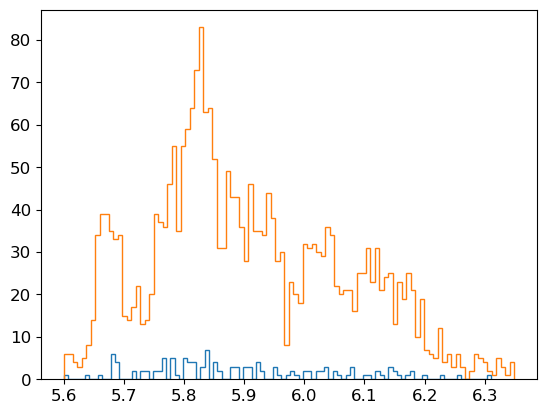

In [22]:
# plot the redshift distribution of the quasars and the randoms
# normalizing the number of randoms to the number of quasars
rand_ra, rand_dec, rand_red = make_rand_cat_ps1(20, red_col_schind_23)


plt.show()

In [ ]:
with plt.style.context('seaborn-v0_8'):
    fig, ax = plt.subplots(figsize = (7,7))
    ax.scatter(red_col_schind_23, mag_col_schind_23, color='navy', edgecolors='white')
    ax.set_xlabel('redshift')
    ax.set_ylabel(r'$M_{1450}$')
    plt.rcParams.update({'font.size': 12})



In [ ]:
step = 0.05
bins = np.arange(np.min(red_col_schind_23), np.max(red_col_schind_23) + step, step)

with plt.style.context('seaborn-v0_8-notebook'):
    mpl.rcParams['xtick.labelsize'] = 'medium'
    mpl.rcParams['ytick.labelsize'] = 'medium'
    mpl.rcParams['font.size'] = 18.0
    fig, (ax, ax2) = plt.subplots(1, 2, figsize=(15,7))
    # hist, bins = np.histogram(red_col_schind_23, bins)
    # hist = hist/np.max(hist)
    ax.hist(red_col_schind_23, bins, edgecolor='white', zorder=10)
    ax.grid(zorder=1, alpha=0.3)
    ax.set_xlabel('redshift')
    ax.set_ylabel('number of quasars')
    ax.set_aspect('auto')

    step = 0.18
    bins = np.arange(np.min(mag_col_schind_23), np.max(mag_col_schind_23) + step, step)

    # hist, bins = np.histogram(mag_col_schind_23, bins)
    # hist = hist/np.max(hist)
    ax2.hist(mag_col_schind_23, bins, edgecolor='white', zorder=10)
    ax2.grid(zorder=1, alpha=0.3)
    ax2.set_xlabel(r'$M_{1450}$')
    ax2.set_ylabel('number of quasars')
    ax2.set_aspect('auto')
    plt.show()






In [ ]:
step = 0.18
bins = np.arange(np.min(mag_col_schind_23), np.max(mag_col_schind_23) + step, step)

with plt.style.context('seaborn-v0_8-notebook'):
    plt.rcParams.update({'font.size': 12})
    fig, ax = plt.subplots(figsize=(7,7))
    # hist, bins = np.histogram(mag_col_schind_23, bins)
    # hist = hist/np.max(hist)
    ax.hist(mag_col_schind_23, bins, edgecolor='white', zorder=10)
    ax.grid(zorder=1, alpha=0.3)
    ax.set_xlabel(r'$M_{1450}$')
    ax.set_ylabel('number count')
    ax.set_aspect('auto')

### Plotting the sky, redshift, distribution of random

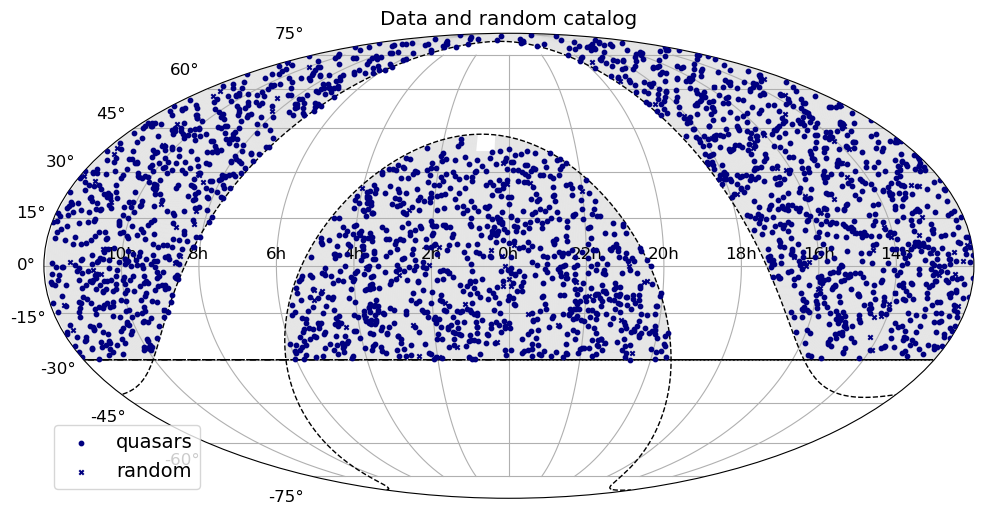

In [16]:
rand_ra, rand_dec, rand_red = make_rand_cat_ps1(20, red_col_schind_23)

#combine the random and the data catalog
all_ra = np.concatenate((ra_col_schind_23, rand_ra))
all_dec = np.concatenate((dec_col_schind_23, rand_dec))
all_red = np.concatenate((red_col_schind_23, rand_red))

# now label the data and the random catalog
mask = np.zeros_like(all_ra, dtype='int')
mask[:len(ra_col_schind_23)] = 1

#in the plot the first element of the mask is the number of unique labels
#the rest of the elements are the labels
mask = np.insert(mask, 0, 2)

ax = plot_sky_map_ps1_v2(all_ra, all_dec, mask, title="Data and random catalog", labels=['quasars', 'random'], mark_size=10)




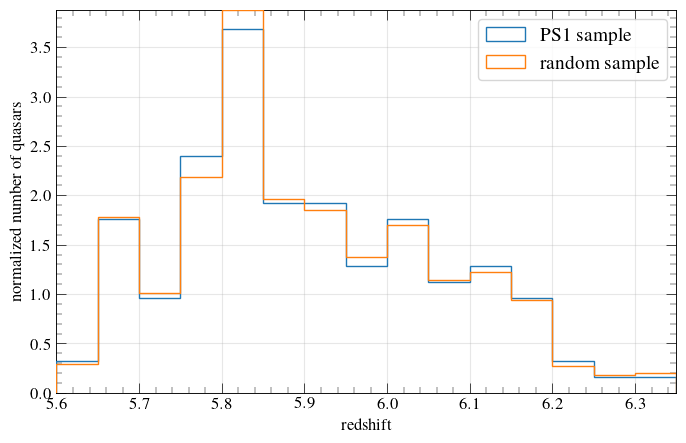

In [21]:
import numpy as np
import matplotlib.pyplot as plt

step = 0.05
bins = np.arange(np.min(red_col_schind_23), np.max(red_col_schind_23) + step, step)

# make random catalog
rand_ra, rand_dec, rand_red = make_rand_cat_ps1(20, red_col_schind_23)

# matplotlib style
plt.style.use('MNRAS_Style.mplstyle')

# mpl.rcParams['font.size'] = 18
fig, ax = plt.subplots(figsize=(8,8))
# hist, bins = np.histogram(red_col_schind_23, bins)
# hist = hist/np.max(hist)
#return the current axes
# ax = plt.gca()
ax.hist(red_col_schind_23, bins, density=True, histtype='step', zorder=10, alpha=1, label = 'PS1 sample')
ax.grid(zorder=1, alpha=0.3)
ax.set_xlabel('redshift')
ax.set_ylabel('number density')

# hist, bins = np.histogram(red_col_schind_23, bins)
# hist = hist/np.max(hist)
ax.hist(rand_red, bins, density=True, histtype='step', zorder=10, alpha =1, label = 'random sample')
ax.grid(zorder=1, alpha=0.3)
ax.set_xlabel('redshift')
ax.set_ylabel('normalized number of quasars')

# set the aspect ratio the golden ratio, longer side is horizontal.
ax.set_box_aspect(1/1.618)

plt.legend()

# Save the plot as a pdf file.
plt.savefig(PLOT_DIRECTORY + "redshift_distribution_PS1.pdf", bbox_inches='tight')
 

### Finding the redshift space clustering for PS1

#### Creating the random catalog

In [ ]:
rand_ra, rand_dec, rand_red = make_rand_cat_ps1(20, red_col_schind_23)

step = 0.05
bins = np.arange(np.min(red_col_schind_23), np.max(red_col_schind_23) + step, step)

hist1, edges, im = plt.hist(red_col_schind_23, bins, histtype='step', density=True, label='PS1 quasars')
#hist2, edges, im = plt.hist(rand_red, bins, histtype='step', density=True, label='random catalog')
plt.legend()
plt.xlabel('z')
plt.ylabel('n(z)')
plt.title('Redshift distribution')
plot_sky_map_ps1(rand_ra, rand_dec, ['quasars'], mark_size=1, title='distribution of random catalog')

#### finding the redshift clustering

In [ ]:
rand_ra, rand_dec, rand_red = make_rand_cat_ps1(20, red_col_schind_23)
s_bins = np.geomspace(30,2000, 20)
print(s_bins)

fig, (ax, ax2) = find_xi_s(ra_col_schind_23, dec_col_schind_23, red_col_schind_23, s_bins, file_name="ps1_redshift_space_corr_table_real_signal.txt", rand_ra=rand_ra, rand_dec=rand_dec,\
                        rand_red=rand_red, extra=True, fit=True)
ax.set_yscale('linear')
ax.set_ylim(-10,20)

#### Doing the mcmc analysis

In [ ]:
fign, axn = plt.subplots(figsize=(7,7))
axn.axhline(0, ls = '--', lw = 0.5, c = 'black')

for i in range(100):
    rand_ra, rand_dec, rand_red = make_rand_cat_ps1(20, red_col_schind_23)
    s_bins = np.geomspace(30,2000, 20)
    s_mid, xi_s, xi_s_error = find_xi_s(ra_col_schind_23, dec_col_schind_23, red_col_schind_23, s_bins, file_name="temp.txt", rand_ra=rand_ra, rand_dec=rand_dec,\
                            rand_red=rand_red, ret_result=True)
    plt.close()

    axn.plot(s_mid, xi_s, '*-')
    axn.set_ylim(-2, 20)

axn.errorbar(s_mid, xi_s, xi_s_error, fmt = '*-')

In [ ]:
def model(theta, s):
    print(theta)
    s0, delta = theta
    return np.power(s/s0, -delta)

model_v = np.vectorize(model, excluded=['theta'])

def lnlike(theta, s_mid, xi_s, xi_s_error):
    xi_s_mod = model(theta, s_mid)

    Lnlike = np.sum(np.power((xi_s - xi_s_mod)/(xi_s_error), 2) * (-0.5))
    return Lnlike

def lnprior(theta):
    s0_min, s0_max = 0, 300
    delta_min, delta_max = 0, 5

    s0, delta = theta
    if ((s0_min <= s0 <= s0_max) & (delta_min <= delta <= delta_max)):
        return 0.0
    else:
        return -np.inf

def lnprob(theta, s_mid, xi_s, xi_s_error):
    lp = lnprior(theta)
    if np.isinf(lp):
        return -np.inf
    else:
        return lp + lnlike(theta, s_mid, xi_s, xi_s_error)

In [ ]:
xi_s_array = 0
xi_s_error_array = 0
DD_count_array = 0
RR_count_array = 0
DR_count_array = 0
num_runs = 1000

for i in range(num_runs):
    rand_ra, rand_dec, rand_red = make_rand_cat_ps1(20, red_col_schind_23)
    s_bins = np.arange(30,2000, 30)
    s_mid, xi_s, xi_s_error, DD_count, RR_count, DR_count= find_xi_s(ra_col_schind_23, dec_col_schind_23, red_col_schind_23, s_bins, file_name="temp.txt", rand_ra=rand_ra, rand_dec=rand_dec,\
                            rand_red=rand_red, ret_result=True)
    plt.close()

    xi_s_array += xi_s/num_runs
    xi_s_error_array += xi_s_error/num_runs
    DD_count_array += DD_count/num_runs
    RR_count_array += RR_count/num_runs
    DR_count_array += DR_count/num_runs
    # axn.plot(s_mid, xi_s, '*-')
    # axn.set_ylim(-2, 20)

# axn.errorbar(s_mid, xi_s, xi_s_error, fmt = '*-')
# xi_s = np.mean(xi_s_array, axis=0)
# xi_s_error = np.mean(xi_s_error_array, axis=0)

#-----------------------------------------------------------------



In [ ]:
mpl.rcParams['font.size'] = 18
fign, axn = plt.subplots(figsize=(14,7))
axn.axhline(0, ls = '--', lw = 0.5, c = 'black')

axn.errorbar(s_mid, xi_s_array, xi_s_error_array, fmt='*', capsize=3)
axn.set_ylabel(r'$\xi(s)$')
axn.set_xlabel(r'$s (h^{-1}Mpc)$')

def write_table_latex(s, xi, xi_err, DD, RR, DR):
    file_name = "latex_table.txt"
    file = open(DP2_DIRECTORY + "Data/" + file_name + ".txt", 'w')

    for i in range(len(s)):
        file.write(f'{s[i]:5.1f} &  {DD[i]:4.1f}  &  {RR[i]:4.2f}  & {DR[i]:4.2f}  & {xi[i]:8.3f} &  {xi_err[i]:8.3f} \\\\\n')
    file.close()

write_table_latex(s_mid, xi_s_array, xi_s_error_array, DD_count_array, RR_count_array, DR_count_array)

In [ ]:
pos = ~xi_s_array.mask
xi_val = np.array(xi_s_array[pos])
s_val = np.array(s_mid[pos])
xi_err = np.array(xi_s_error_array[pos])

initial = np.array([100.0, 2.0])
ndim = len(initial)

nwalkers = 100

data = (s_val[2:], xi_val[2:], xi_err[2:])

p0 = [np.array(initial) + 1e-7 * np.random.randn(ndim) for i in range(nwalkers)]

sampler = emcee.EnsembleSampler(nwalkers, ndim, lnprob, args=data)
sampler.run_mcmc(p0, 1000);
sampler.reset()

sampler.run_mcmc(p0, 50000);

samples = sampler.flatchain
print(samples.shape)

import corner
mpl.rcParams['font.size'] = 14
labels = ['s0', 'delta']
fig = corner.corner(samples, show_titles=True, labels=labels, plot_datapoints=True, quantiles=[0.16, 0.5, 0.84])
plt.show()



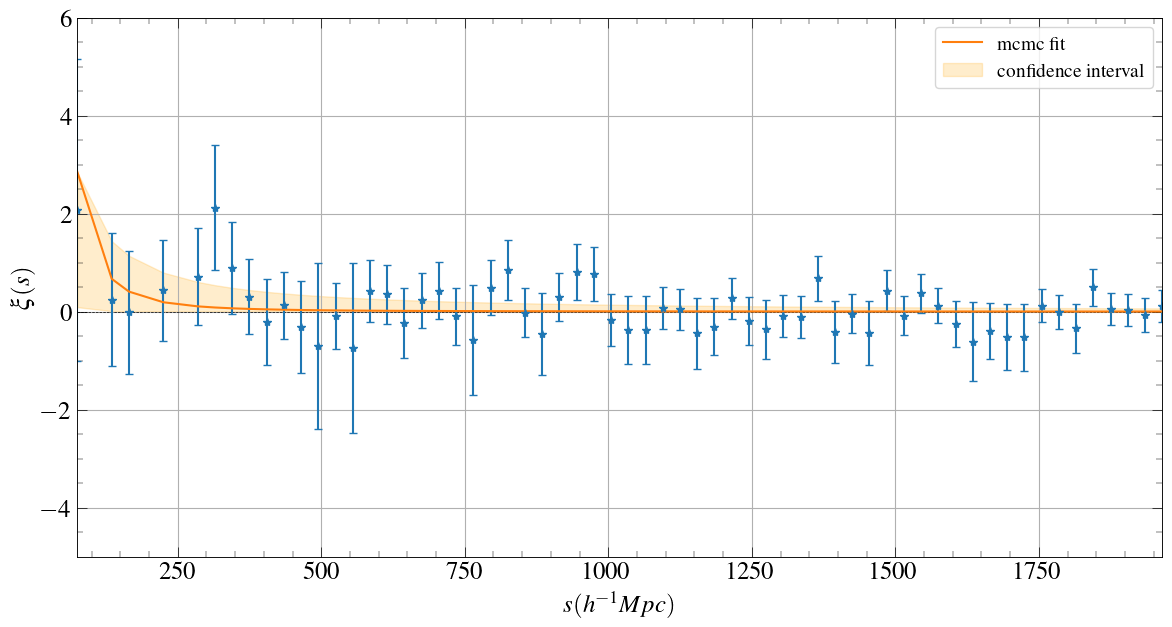

In [24]:
file = open(DP2_DIRECTORY + "Data/" + "latex_table.txt.txt", 'r')
data_here = np.genfromtxt(file) 

s_mid = data_here[:,0]
xi = data_here[:, 8]
xi_err = data_here[:, 10]

loc_here = np.where(~(np.isnan(xi) | np.isnan(xi_err)))

s_mid = s_mid[loc_here]
xi = xi[loc_here]
xi_err = xi_err[loc_here]

mpl.rcParams['font.size'] = 18
fign, axn = plt.subplots(figsize=(14,7))
axn.axhline(0, ls = '--', lw = 0.5, c = 'black')

axn.errorbar(s_mid, xi, xi_err, fmt='*', capsize=3)
axn.set_ylabel(r'$\xi(s)$')
axn.set_xlabel(r'$s (h^{-1}Mpc)$')

fit_clust = pow(s_mid/ 114.66, -2.47)
fit_clust_u = pow(s_mid/ (114.66+69.90), -2.11+0.95)
fit_clust_d = pow(s_mid/ (114.66-74.33), -2.11-1.78)

axn.plot(s_mid, fit_clust, '-', label="mcmc fit")
# axn.plot(s_mid, fit_clust_u, '-', label="mcmc fit")
# axn.plot(s_mid, fit_clust_d, '-', label="mcmc fit")
axn.fill_between(s_mid, fit_clust_d, fit_clust_u, color='orange', alpha=.2, label="confidence interval")
axn.set_ylim(-5,6)
plt.legend()

### Plotting the $s_0$ and $\delta$ vs z graph in the literature and our work

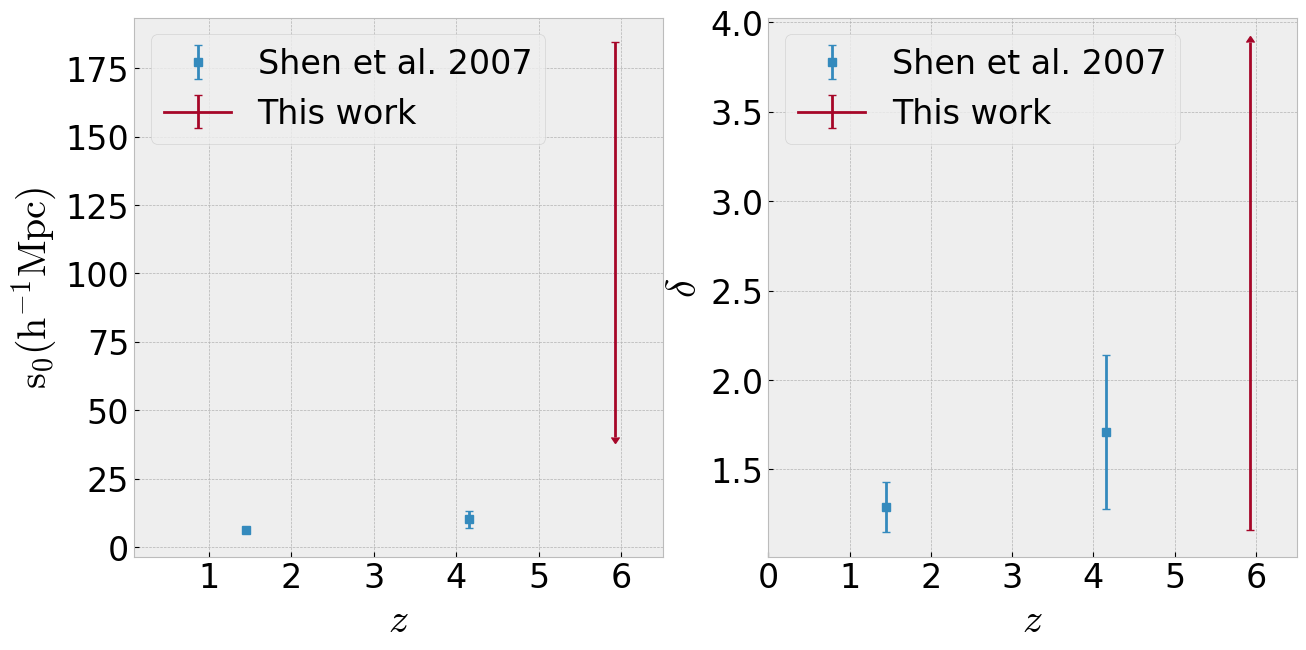

In [14]:
import matplotlib.pyplot as plt
import matplotlib as mpl


with plt.style.context('bmh'):
    mpl.rcParams['font.size'] = 24
    fig, (ax, ax2) = plt.subplots(1, 2, figsize = (15,7))

    shen_z = [(0.8 + 2.1)/2, (2.9 + 5.4)/2]
    shen_s0 = [6.36, 10.16]
    shen_err = [0.89, 3.08]

    ax.errorbar(shen_z, shen_s0, shen_err, fmt='s', capsize=3, label="Shen et al. 2007")
    ax.errorbar((5.54+6.31)/2, 184.56, [144.23], uplims=True, fmt='-', capsize=3, label="This work")

    ax.set_ylabel(r'$\mathrm{s_0 (h^{-1}Mpc)}$', fontsize='larger')
    ax.set_xlabel(r'$z$', fontsize='larger')
    ax.set_xlim(0.1, 6.5)
    ax.legend()

    shen_z = [(0.8 + 2.1)/2, (2.9 + 5.4)/2]
    shen_del = [1.29, 1.71]
    shen_d_err = [0.14, 0.43]

    ax2.errorbar(shen_z, shen_del, shen_d_err, fmt='s', capsize=3, label="Shen et al. 2007")
    ax2.errorbar((5.54+6.31)/2, 1.16, [2.73], fmt='-', lolims=True, capsize=3, label="This work")
    ax2.set_ylabel(r'$\mathrm{\delta}$', fontsize='larger')
    ax2.set_xlabel(r'$z$', fontsize='larger')
    ax2.set_xlim(0, 6.5)
    ax2.legend()

plt.show()

### Making a clustered sample in PS1 footprint

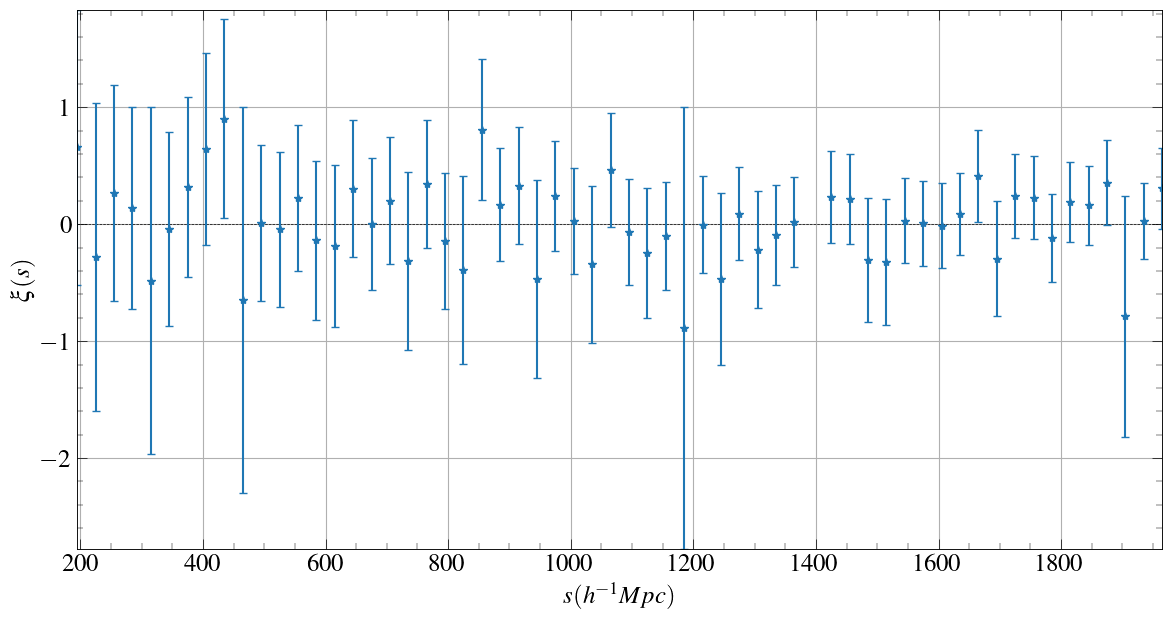

In [26]:
ra, dec, red = make_rand_cat_ps1(1, red_col_schind_23)
find_red_clust_PS1_footprint(ra, dec, red)

In [ ]:
def get_r_from_prob(r0, delta):
    c = np.random.uniform(0, 1, 1)[0]
    A = (1 - delta)/(pow(r0, delta) * (pow(10, 1 - delta) - pow(0.5, 1 - delta)))
    temp1 = (1 - delta)/(A * pow(r0, delta)) * c + pow(0.5, 1 - delta)
    return pow(temp1, 1/(1 - delta))

def make_clust_dist_ps1(num, r0, delta):
    r = np.random.uniform(low_r, up_r)
    phi = np.random.uniform(0, 2 * np.pi, 1)[0]
    z = np.random.uniform(-r, r, 1)[0]
    theta = np.arccos(z/r)
    dat_array = np.array(spher_to_cart(r, theta, phi)).reshape(3,1)
    i = 0

    while i < (num - 1):
        r = get_r_from_prob(r0, delta)
        phi = np.random.uniform(0, 2 * np.pi, 1)[0]
        z = np.random.uniform(-r, r, 1)[0]
        theta = np.arccos(z/r)

        new_add = np.array([r * np.sin(theta) * np.cos(phi), r * np.sin(theta) * np.sin(phi), z])
        new_pt = np.reshape(dat_array[:,-1] + new_add, (3,1))
        if np.sum(pow(new_pt, 2)) < low_r | np.sum(pow(new_pt, 2)) > up_r:
            continue
        
        dat_array = np.append(dat_array, new_pt, axis=1)
        i += 1

    return dat_array

#### Doing a statistical look in the ps1 result.

[-- 2.067091099036916 -- 0.24771666738314177 -0.01438544888359675 --
 0.43656336657159034 -- 0.7090405776121746 2.110916667686036
 0.8897731393240254 0.2926958196581452 -0.2120445208679934
 0.12279626970821166 -0.3203453960766949 -0.6925623931288771
 -0.076816389871791 -0.7240434946832152 0.41244198897546674
 0.34507732329641083 -0.24610114902249425 0.22816401757303312
 0.4132253217501011 -0.10729621823947302 -0.5928852256213346
 0.46592260986879397 0.84444927641706 -0.03145833541846796
 -0.45706264155630383 0.29785144098750715 0.8070767202592094
 0.7539854199882504 -0.17343751223085094 -0.37292591878247294
 -0.39189017731209974 0.08392157966715044 0.05480301940876689
 -0.43134509181792474 -0.30855290747630437 0.2765680467685148
 -0.19267832111154473 -0.37128713261207186 -0.09913651102337577
 -0.11239832612079971 0.6766272516542438 -0.41927037015882784
 -0.03809955697032432 -0.4350786718450504 0.4295148952122221
 -0.08997103988751616 0.37606511412882193 0.12426919149305794
 -0.25438009

ValueError: Unknown format code 'd' for object of type 'float'

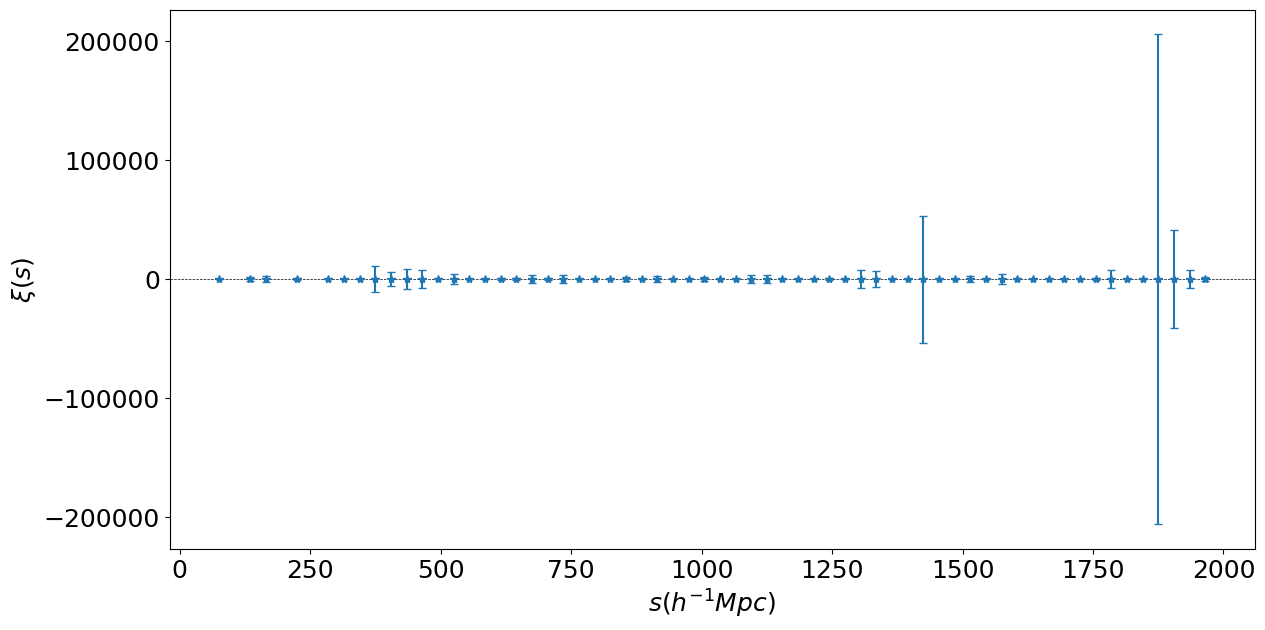

In [21]:
DP2_DIRECTORY = "/home/vibin/MyFolder/WorkDesk/DP2/"

# for i in range(10):
find_red_clust_PS1_footprint(ra_col_schind_23, dec_col_schind_23, red_col_schind_23, write_data=True, file_name_to_write="ps1_redshift_space_corr_table_real_signal")


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import ascii
from astropy import units as u
from astropy.coordinates import SkyCoord, Distance
from astropy.cosmology import LambdaCDM as LCDM
import numpy.ma as ma
import healpy as hp
import matplotlib as mpl
import emcee

## My modules
from Clustering_module import *


DP2_DIRECTORY = "/home/vibin/MyFolder/WorkDesk/DP2/"

cosmo = LCDM(H0=71, Om0=0.26, Ode0=0.74, Ob0=0.0435)

schind_23_file_name = DP2_DIRECTORY + "Data/apjaca7cat7_ascii.txt"
schind_23_data = open(schind_23_file_name, 'r')
ra_col_schind_23 = []
dec_col_schind_23 = []
red_col_schind_23 = []
mag_col_schind_23 = []

skip_rows = 6
for line in schind_23_data:
    if (skip_rows > 0):
        skip_rows -= 1
        continue
    split_line = line.split()
    quasar_name = split_line[0] 
    red_col_schind_23.append(float(split_line[2]))
    ra_col_schind_23.append(float(quasar_name[4:13]))
    dec_col_schind_23.append(float(quasar_name[13:21]))

    mag_col_schind_23.append(float(split_line[3]))
    
ra_col_schind_23 = np.array(ra_col_schind_23)
dec_col_schind_23 = np.array(dec_col_schind_23)
red_col_schind_23 = np.array(red_col_schind_23)
mag_col_schind_23 = np.array(mag_col_schind_23)

DP2_DIRECTORY = "/home/vibin/MyFolder/WorkDesk/DP2/"


def find_red_clust_PS1_footprint(data_ra, data_dec, data_red, plot_fig=True, write_data=False, file_name_to_write=None):

    if write_data:
        if file_name_to_write == None:
            raise Exception("Please give a file name to write data")
        
    s_bins = np.arange(30,2000, 30)

    xi_s_array = ma.zeros_like(s_bins[:-1], dtype=float)
    xi_s_error_array = ma.zeros_like(s_bins[:-1], dtype=float)
    DD_count_array = ma.zeros_like(s_bins[:-1], dtype=float)
    RR_count_array = ma.zeros_like(s_bins[:-1], dtype=float)
    DR_count_array = ma.zeros_like(s_bins[:-1], dtype=float)
    num_runs = 1000

    for i in range(num_runs):
        rand_ra, rand_dec, rand_red = make_rand_cat_ps1(20, data_red)
        s_mid, xi_s, xi_s_error, DD_count, RR_count, DR_count= find_xi_s(data_ra, data_dec, data_red, s_bins, rand_ra=rand_ra, rand_dec=rand_dec,\
                                rand_red=rand_red, ret_result=True)
        plt.close()

        xi_s_array += xi_s
        xi_s_error_array += (xi_s_error)**2
        DD_count_array += DD_count
        RR_count_array += RR_count
        DR_count_array += DR_count

    xi_s_array = xi_s_array/num_runs
    xi_s_error_array = xi_s_error_array**0.5
    DD_count_array = DD_count_array/num_runs
    RR_count_array = RR_count_array/num_runs
    DR_count_array = DR_count_array/num_runs

    print(xi_s_array)
    print(xi_s_error_array)

    if plot_fig:
        mpl.rcParams['font.size'] = 18
        fign, axn = plt.subplots(figsize=(14,7))
        axn.axhline(0, ls = '--', lw = 0.5, c = 'black')

        axn.errorbar(s_mid, xi_s_array, xi_s_error_array, fmt='*', capsize=3)
        axn.set_ylabel(r'$\xi(s)$')
        axn.set_xlabel(r'$s (h^{-1}Mpc)$')
    
    if write_data:
        file = open(DP2_DIRECTORY + "Data/" + file_name_to_write + ".txt", 'w')
        file.write('  s_mid       DD      RR      DR      xi_s     Delta xi_s\n')
        for i in range(len(s_mid)):
            file.write(f'{s_mid[i]:9.3f}   {DD_count_array[i]:5d}    {RR_count_array[i]:5d}   {DR_count_array[i]:5d}   {xi_s_array[i]:8.5f}   {xi_s_error_array[i]:8.5f}\n')
        file.close()


In [3]:
def find_xi_s_temp(ra, dec, red, s_bins, rand_ra = None, rand_dec = None, rand_red = None):
    #Find the redshift space clustering

    if((rand_ra is None) and (rand_dec is None) and (rand_red is None)):
        raise ValueError

    # s_array = find_s_bined(ra, dec, red)
    # rand_s_array = find_s_bined(rand_ra, rand_dec, rand_red)
    # cross_s_array = find_s_bined(ra, dec ,red, rand_ra_col=rand_ra, rand_dec_col=rand_dec, rand_red_col=rand_red)

    s_mid = (s_bins[:-1] + s_bins[1:])/2

    # s_hist = (np.histogram(s_array, s_bins)[0]).astype(int)
    # rand_s_hist = (np.histogram(rand_s_array, s_bins)[0]).astype(int)
    # cross_s_hist = (np.histogram(cross_s_array, s_bins)[0]).astype(int)

    s_hist = (pair_count_corrfunc(ra, dec, red, s_bins)[:,3]).astype(int)
    rand_s_hist = (pair_count_corrfunc(rand_ra, rand_dec, rand_red, s_bins)[:,3]).astype(int)
    cross_s_hist = (pair_count_corrfunc(ra, dec, red, s_bins, rand_ra_col=rand_ra, rand_dec_col=rand_dec, rand_red_col=rand_red)[:,3]).astype(int)
    s_hist_norm = (len(ra) * (len(ra) - 1))/2
    rand_hist_norm = (len(rand_ra) * (len(rand_ra) - 1))/2
    cross_hist_norm = len(ra) * len(rand_ra)

    unfin_pos = np.where(s_hist * rand_s_hist * cross_s_hist == 0)

    with np.errstate(divide='ignore', invalid='ignore'):
        xi_s = (s_hist/s_hist_norm - 2 * cross_s_hist/cross_hist_norm + rand_s_hist/rand_hist_norm)/(rand_s_hist/rand_hist_norm)
    xi_s_masked = ma.array(xi_s)
    xi_s_masked[unfin_pos] = ma.masked

    with np.errstate(divide='ignore', invalid='ignore'):
        xi_s_error = (1 + xi_s)/np.sqrt(np.minimum(s_hist, len(ra)))
    xi_s_masked_error = ma.array(xi_s_error)
    xi_s_masked_error[unfin_pos] = ma.masked

    return s_mid, xi_s_masked, xi_s_masked_error, s_hist, rand_s_hist, cross_s_hist

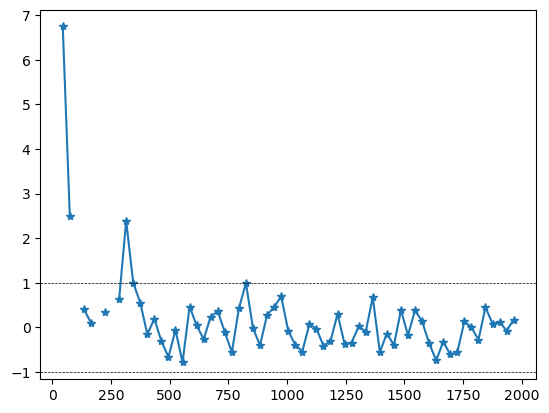

In [43]:
s_bins = np.arange(30,2000, 30)

rand_ra, rand_dec, rand_red = make_rand_cat_ps1(40, red_col_schind_23)
s_mid, xi_s, xi_s_error, DD_count, RR_count, DR_count= find_xi_s_temp(ra_col_schind_23, dec_col_schind_23, red_col_schind_23, s_bins, rand_ra=rand_ra, rand_dec=rand_dec,\
                                rand_red=rand_red)

plt.plot(s_mid, xi_s, '*-')

# plot horizontal line at 1 and -1
plt.axhline(1, ls = '--', lw = 0.5, c = 'black')
plt.axhline(-1, ls = '--', lw = 0.5, c = 'black')

In [53]:
s_bins = np.arange(30,2000, 30)
count_lone = 0

for i in range(1000):
    rand_ra, rand_dec, rand_red = make_rand_cat_ps1(60, red_col_schind_23)
    s_mid, xi_s, xi_s_error, DD_count, RR_count, DR_count= find_xi_s_temp(ra_col_schind_23, dec_col_schind_23, red_col_schind_23, s_bins, rand_ra=rand_ra, rand_dec=rand_dec,\
                                    rand_red=rand_red)
    
    # Find the number of points where xi_s is less than -1
    count_lone += len(ma.where(xi_s < -1)[0])

print(count_lone)

8


In [ ]:
5 --- for rand 60x
14 --- for rand 50x
33 --- for rand 40x
74 --- for rand 30x
137 --- for rand 20x

In [54]:
s_bins = np.arange(30,2000, 30)

xi_s_array = ma.zeros_like(s_bins[:-1], dtype=float)
xi_s_error_array = ma.zeros_like(s_bins[:-1], dtype=float)
DD_count_array = ma.zeros_like(s_bins[:-1], dtype=float)
RR_count_array = ma.zeros_like(s_bins[:-1], dtype=float)
DR_count_array = ma.zeros_like(s_bins[:-1], dtype=float)

xi_s_array_exc = ma.zeros_like(s_bins[:-1], dtype=float)
xi_s_error_array_exc = ma.zeros_like(s_bins[:-1], dtype=float)
num_runs = 1000

num_exc = 0

for i in range(num_runs):
    rand_ra, rand_dec, rand_red = make_rand_cat_ps1(60, red_col_schind_23)
    s_mid, xi_s, xi_s_error, DD_count, RR_count, DR_count= find_xi_s_temp(ra_col_schind_23, dec_col_schind_23, red_col_schind_23, s_bins, rand_ra=rand_ra, rand_dec=rand_dec,\
                                    rand_red=rand_red)

    xi_s_array += xi_s
    xi_s_error_array += (xi_s_error)**2
    DD_count_array += DD_count
    RR_count_array += RR_count
    DR_count_array += DR_count

    if len(ma.where(xi_s < -1)[0]) > 0:
        num_exc += 1
        continue 

    xi_s_array_exc += xi_s
    xi_s_error_array_exc += (xi_s_error)**2

xi_s_array = xi_s_array/num_runs
xi_s_error_array = (xi_s_error_array/num_runs)**0.5
DD_count_array = DD_count_array/num_runs
RR_count_array = RR_count_array/num_runs
DR_count_array = DR_count_array/num_runs

xi_s_array_exc = xi_s_array_exc/(num_runs - num_exc)
xi_s_error_array_exc = (xi_s_error_array_exc/(num_runs - num_exc))**0.5

# plt.plot(s_mid, xi_s_array, '*-')

# # plot horizontal line at 1 and -1
# plt.axhline(1, ls = '--', lw = 0.5, c = 'black')
# plt.axhline(-1, ls = '--', lw = 0.5, c = 'black')

# print xi_s_array and xi_s_array_exc side by side

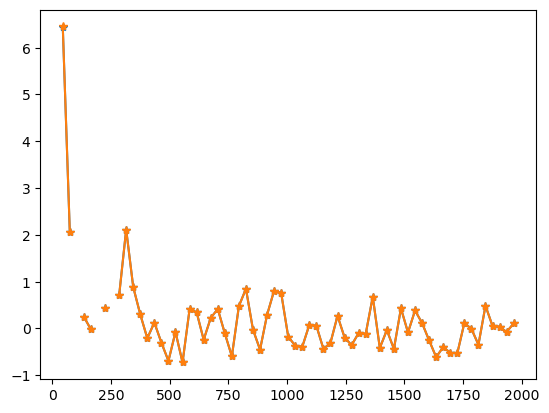

In [57]:
plt.plot(s_mid, xi_s_array, '*-')
plt.plot(s_mid, xi_s_array_exc, '*-')

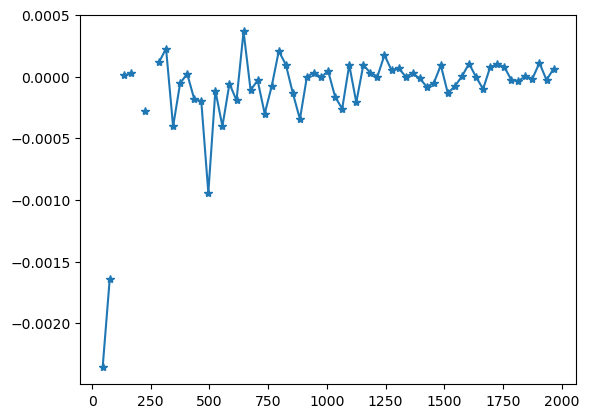

In [59]:
plt.plot(s_mid, xi_s_error_array - xi_s_error_array_exc, '*-')

In [4]:
s_bins = np.arange(30,2000, 30)

xi_s_array = ma.zeros_like(s_bins[:-1], dtype=float)
xi_s_error_array = ma.zeros_like(s_bins[:-1], dtype=float)
DD_count_array = ma.zeros_like(s_bins[:-1], dtype=float)
RR_count_array = ma.zeros_like(s_bins[:-1], dtype=float)
DR_count_array = ma.zeros_like(s_bins[:-1], dtype=float)

xi_s_array_exc = ma.zeros_like(s_bins[:-1], dtype=float)
xi_s_error_array_exc = ma.zeros_like(s_bins[:-1], dtype=float)
num_runs = 1000

for i in range(num_runs):
    rand_ra, rand_dec, rand_red = make_rand_cat_ps1(60, red_col_schind_23)
    s_mid, xi_s, xi_s_error, DD_count, RR_count, DR_count= find_xi_s_temp(ra_col_schind_23, dec_col_schind_23, red_col_schind_23, s_bins, rand_ra=rand_ra, rand_dec=rand_dec,\
                                    rand_red=rand_red)

    xi_s_array += xi_s
    xi_s_error_array += (xi_s_error)**2
    DD_count_array += DD_count
    RR_count_array += RR_count
    DR_count_array += DR_count

xi_s_array = xi_s_array/num_runs
xi_s_error_array = (xi_s_error_array/num_runs)**0.5
DD_count_array = DD_count_array/num_runs
RR_count_array = RR_count_array/num_runs
DR_count_array = DR_count_array/num_runs

[Warning] The CPU supports AVX2 but the compiler does not.  Can you try another compiler?
[Warning] The CPU supports AVX but the compiler does not.  Can you try another compiler?
[Warning] The CPU supports SSE4.2 but the compiler does not.  Can you try another compiler?
[Warning] The CPU supports SSE4.1 but the compiler does not.  Can you try another compiler?
[Warning] The CPU supports SSSE3 but the compiler does not.  Can you try another compiler?


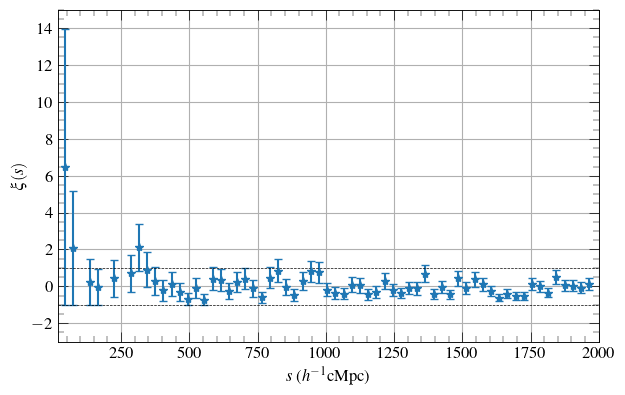

In [5]:
# matplotlib style
plt.style.use('MNRAS_Style.mplstyle')

# make an errorbar plot of xi_s_array with xi_s_error_array as the errorbars
plt.errorbar(s_mid, xi_s_array, xi_s_error_array, fmt='*', capsize=3)

# add the axis labels
plt.xlabel(r'$s$ ($h^{-1}$cMpc)')
plt.ylabel(r'$\xi(s)$')

# set axis limits
plt.xlim(20, 2000)
plt.ylim(-3, 15)

# Draw horizontal lines at 1 and -1
plt.axhline(1, ls = '--', lw = 0.5, c = 'black')
plt.axhline(-1, ls = '--', lw = 0.5, c = 'black')

In [9]:
#define DP2 directory
DP2_DIRECTORY = "/home/vibin/MyFolder/WorkDesk/DP2/"

# save s_mid, DD_count_array, RR_count_array, DR_count_array, xi_s_array, xi_s_error_array to a file
file = open(DP2_DIRECTORY + "Data/" + "ps1_redshift_space_corr_table_real_signal.txt", 'w')
file.write('s_mid       DD      RR      DR      xi_s     Delta xi_s\n')
for i in range(len(s_mid)):
    file.write(f'{s_mid[i]:9.3f}   {DD_count_array[i]:9.3f}    {RR_count_array[i]:9.3f}   {DR_count_array[i]:9.3}   {xi_s_array[i]:8.5f}   {xi_s_error_array[i]:8.5f}\n')
file.close()


/tmp/ipykernel_99137/3160913632.py:8: FutureWarning: Format strings passed to MaskedConstant are ignored, but in future may error or produce different behavior
  file.write(f'{s_mid[i]:9.3f}   {DD_count_array[i]:9.3f}    {RR_count_array[i]:9.3f}   {DR_count_array[i]:9.3}   {xi_s_array[i]:8.5f}   {xi_s_error_array[i]:8.5f}\n')


##### Doing MCMC

In [4]:
def model(theta, s):
    s0, delta = theta
    return np.power(s/s0, -delta)

model_v = np.vectorize(model, excluded=['theta'])

def lnlike(theta, s_mid, xi_s, xi_s_error):
    xi_s_mod = model(theta, s_mid)

    Lnlike = np.sum(np.power((xi_s - xi_s_mod)/(xi_s_error), 2) * (-0.5))
    return Lnlike

def lnprior(theta):
    s0_min, s0_max = 0, 300
    delta_min, delta_max = 0, 5

    s0, delta = theta
    if ((s0_min <= s0 <= s0_max) & (delta_min <= delta <= delta_max)):
        return 0.0
    else:
        return -np.inf

def lnprob(theta, s_mid, xi_s, xi_s_error):
    lp = lnprior(theta)
    if np.isinf(lp):
        return -np.inf
    else:
        return lp + lnlike(theta, s_mid, xi_s, xi_s_error)

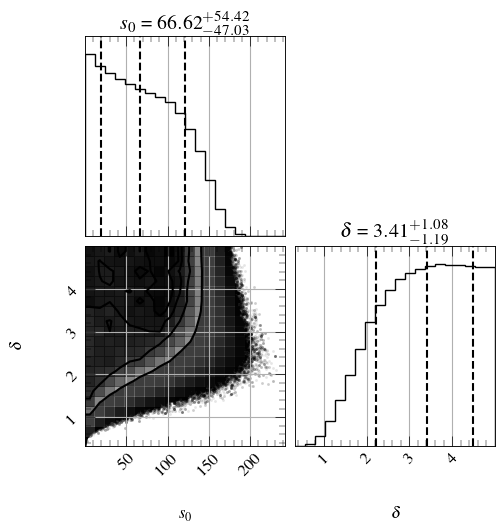

In [6]:
import numpy as np
import emcee
import matplotlib.pyplot as plt

# define DP2 directory
DP2_DIRECTORY = "/home/vibin/MyFolder/WorkDesk/DP2/"

#define plot directory
PLOT_DIRECTORY = "/home/vibin/MyFolder/WorkDesk/DP2/Plots/"

# read the data from the ps1_redshift_space_corr_table_real_signal.txt file
file = open(DP2_DIRECTORY + "Data/" + "ps1_redshift_space_corr_table_real_signal.txt", 'r')
data_here = np.genfromtxt(file, skip_header=1)

s_mid = data_here[:,0]
xi = data_here[:, 4]
xi_err = data_here[:, 5]

loc_here = np.where(~(np.isnan(xi) | np.isnan(xi_err)))

s_val = s_mid[loc_here]
xi_val = xi[loc_here]
xi_err = xi_err[loc_here]

initial = np.array([100.0, 2.0])
ndim = len(initial)

nwalkers = 100

data = (s_val[2:], xi_val[2:], xi_err[2:])

p0 = [np.array(initial) + 1e-7 * np.random.randn(ndim) for i in range(nwalkers)]

sampler = emcee.EnsembleSampler(nwalkers, ndim, lnprob, args=data)
sampler.run_mcmc(p0, 1000);
sampler.reset()

sampler.run_mcmc(p0, 50000);

samples = sampler.flatchain

import corner

# matplotlib style
plt.style.use('MNRAS_Style.mplstyle')

labels = [r'$s_0$', r'$\delta$']
fig = corner.corner(samples, show_titles=True, labels=labels, plot_datapoints=True, quantiles=[0.16, 0.5, 0.84])

# Save the plot as a pdf file.
plt.savefig(PLOT_DIRECTORY + "corner_plot_PS1.pdf", bbox_inches='tight')

In [8]:
def model2(theta, s):
    s0 = theta
    return np.power(s/s0, -2)

model_v = np.vectorize(model, excluded=['theta'])

def lnlike(theta, s_mid, xi_s, xi_s_error):
    xi_s_mod = model2(theta, s_mid)

    Lnlike = np.sum(np.power((xi_s - xi_s_mod)/(xi_s_error), 2) * (-0.5))
    return Lnlike

def lnprior(theta):
    s0_min, s0_max = 0, 300

    s0 = theta
    if ((s0_min <= s0 <= s0_max)):
        return 0.0
    else:
        return -np.inf

def lnprob(theta, s_mid, xi_s, xi_s_error):
    lp = lnprior(theta)
    if np.isinf(lp):
        return -np.inf
    else:
        return lp + lnlike(theta, s_mid, xi_s, xi_s_error)

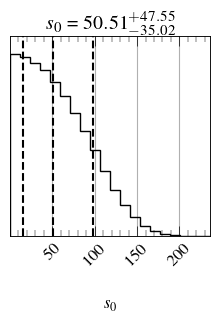

In [9]:
import numpy as np
import emcee
import matplotlib.pyplot as plt

# define DP2 directory
DP2_DIRECTORY = "/home/vibin/MyFolder/WorkDesk/DP2/"

#define plot directory
PLOT_DIRECTORY = "/home/vibin/MyFolder/WorkDesk/DP2/Plots/"

# read the data from the ps1_redshift_space_corr_table_real_signal.txt file
file = open(DP2_DIRECTORY + "Data/" + "ps1_redshift_space_corr_table_real_signal.txt", 'r')
data_here = np.genfromtxt(file, skip_header=1)

s_mid = data_here[:,0]
xi = data_here[:, 4]
xi_err = data_here[:, 5]

loc_here = np.where(~(np.isnan(xi) | np.isnan(xi_err)))

s_val = s_mid[loc_here]
xi_val = xi[loc_here]
xi_err = xi_err[loc_here]

initial = np.array([100.0])
ndim = len(initial)

nwalkers = 100

data = (s_val[2:], xi_val[2:], xi_err[2:])

p0 = [np.array(initial) + 1e-7 * np.random.randn(ndim) for i in range(nwalkers)]

sampler = emcee.EnsembleSampler(nwalkers, ndim, lnprob, args=data)
sampler.run_mcmc(p0, 1000);
sampler.reset()

sampler.run_mcmc(p0, 50000);

samples = sampler.flatchain

import corner

# matplotlib style
plt.style.use('MNRAS_Style.mplstyle')

labels = [r'$s_0$']
fig = corner.corner(samples, show_titles=True, labels=labels, plot_datapoints=True, quantiles=[0.16, 0.5, 0.84])

# Save the plot as a pdf file.
plt.savefig(PLOT_DIRECTORY + "corner_plot_PS1.pdf", bbox_inches='tight')

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


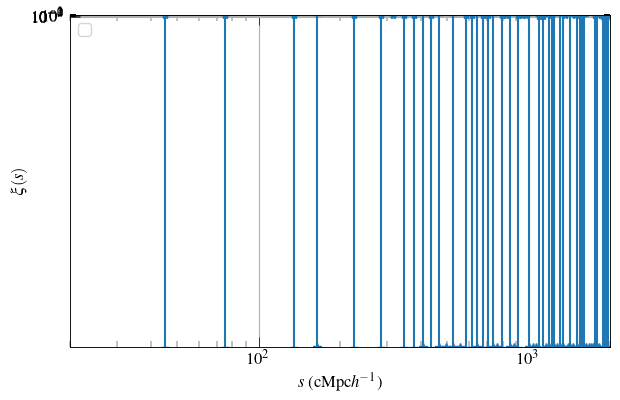

In [3]:
import numpy as np
import emcee
import matplotlib.pyplot as plt

# define DP2 directory
DP2_DIRECTORY = "/home/vibin/MyFolder/WorkDesk/DP2/"

#define plot directory
PLOT_DIRECTORY = "/home/vibin/MyFolder/WorkDesk/DP2/Plots/"

# read the data from the ps1_redshift_space_corr_table_real_signal.txt file
file = open(DP2_DIRECTORY + "Data/" + "ps1_redshift_space_corr_table_real_signal.txt", 'r')
data_here = np.genfromtxt(file, skip_header=1)

s_mid = data_here[:,0]
xi = data_here[:, 4]
xi_err = data_here[:, 5]

# matplotlib style
plt.style.use('MNRAS_Style.mplstyle')

# make an errorbar plot of xi_s_array with xi_s_error_array as the errorbars
plt.errorbar(s_mid, xi, xi_err, fmt='*', capsize=3)

# add the axis labels
plt.xlabel(r'$s$ (cMpc$h^{-1}$)')
plt.ylabel(r'$\xi(s)$')

# set axis limits
plt.xlim(20, 2000)
plt.ylim(-3, 15)

# Draw horizontal lines at 1 and -1
plt.axhline(1, ls = '--', lw = 0.5, c = 'black')
plt.axhline(-1, ls = '--', lw = 0.5, c = 'black')

# fit_clust = pow(s_mid/ 50.51, -2.0)
# fit_clust_u = pow(s_mid/ (50.51+47.55), -2.0)
# fit_clust_d = 0

# plt.fill_between(s_mid, fit_clust_d, fit_clust_u, color='orange', alpha=.5, label="confidence interval")

plt.xscale('log')
plt.yscale('log')

plt.legend()

# Save the plot as a pdf file.
plt.savefig(PLOT_DIRECTORY + "xi_s_PS1.pdf", bbox_inches='tight')